Name- Kanika shekhawat

Roll No.- 8025320045

Q1. You are a data analyst at an e-commerce company. Your task is to analyze sales data, clean and process it, perform statistical analysis, and generate visual insights to help the business make informed decisions.

In [ ]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Part I: Randomized Sales Data Generation (NumPy)

In [ ]:
#Using Roll No as seed value to generate unique data
Roll_No = 45
np.random.seed(Roll_No)

Step 2: Generate Random Sales Data

A NumPy array of shape (12, 4) is created to represent monthly sales for 12 months across 4 product categories:
- Electronics
- Clothing
- Home & Kitchen
- Sports

In [ ]:
#Step 2: Generating Random Sales Data
# Sales values between 1000 and 5000 units per month
sales_data = np.random.randint(1000, 5001, size=(12, 4))
print(sales_data)
print(f"\nShape: {sales_data.shape}")

[[1426 2709 1424 4573]
 [4254 4828 4954 1908]
 [3501 4973 3686 1892]
 [2201 2682 2572 4724]
 [1224 2874 2507 2946]
 [2414 3363 1417 3916]
 [4471 2628 1079 4400]
 [3019 4368 1317 4262]
 [1457 2467 3244 1204]
 [1260 4388 1826 1287]
 [4269 3727 1888 2357]
 [4233 4405 1902 4307]]

Shape: (12, 4)


Step 3: Convert NumPy Array to Pandas DataFrame

The NumPy array is converted into a Pandas DataFrame with:
- Columns as product categories
- Index as months from January to December

In [ ]:
#Step 3: Converting to Pandas DataFrame
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']

df = pd.DataFrame(sales_data, index=months, columns=categories)

print("Sales Dataframe: ")
print(df)

Sales Dataframe: 
     Electronics  Clothing  Home & Kitchen  Sports
Jan         1426      2709            1424    4573
Feb         4254      4828            4954    1908
Mar         3501      4973            3686    1892
Apr         2201      2682            2572    4724
May         1224      2874            2507    2946
Jun         2414      3363            1417    3916
Jul         4471      2628            1079    4400
Aug         3019      4368            1317    4262
Sep         1457      2467            3244    1204
Oct         1260      4388            1826    1287
Nov         4269      3727            1888    2357
Dec         4233      4405            1902    4307


Part II: Data Manipulation and Analysis (Pandas)

Step 1: Display First 5 Rows and Summary Statistics

The first 5 rows help inspect the data structure, and summary statistics provide information such as count, mean, standard deviation, minimum, quartiles, and maximum values.

In [ ]:
#Step 1: First 5 Rows & Summary Statistics
print("First 5 Rows: ")
print(df.head())
print("\nSummary Statistics: ")
print(df.describe())

First 5 Rows: 
     Electronics  Clothing  Home & Kitchen  Sports
Jan         1426      2709            1424    4573
Feb         4254      4828            4954    1908
Mar         3501      4973            3686    1892
Apr         2201      2682            2572    4724
May         1224      2874            2507    2946

Summary Statistics: 
       Electronics     Clothing  Home & Kitchen       Sports
count    12.000000    12.000000       12.000000    12.000000
mean   2810.750000  3617.666667     2318.000000  3148.000000
std    1304.205793   939.662060     1149.142447  1357.808528
min    1224.000000  2467.000000     1079.000000  1204.000000
25%    1449.250000  2702.250000     1422.250000  1904.000000
50%    2716.500000  3545.000000     1895.000000  3431.000000
75%    4238.250000  4392.250000     2740.000000  4330.250000
max    4471.000000  4973.000000     4954.000000  4724.000000


Step 2: Calculate Total Sales

Two types of totals are calculated:
- Total sales per category
- Total sales per month

In [ ]:
#Step 2: Total Sales per Category & per Month
#Sum down each column
total_per_category = df.sum(axis=0)
#Sum across each row
total_per_month = df.sum(axis=1)
print("Total Sales per Category: ")
print(total_per_category)
print("\nTotal Sales per Month: ")
print(total_per_month)

Total Sales per Category: 
Electronics       33729
Clothing          43412
Home & Kitchen    27816
Sports            37776
dtype: int64

Total Sales per Month: 
Jan    10132
Feb    15944
Mar    14052
Apr    12179
May     9551
Jun    11110
Jul    12578
Aug    12966
Sep     8372
Oct     8761
Nov    12241
Dec    14847
dtype: int64


Step 3: Calculate Average Sales Growth Between Consecutive Months

The percentage change between consecutive months is calculated for each category using `pct_change()`.  Then, the average growth rate is computed for each category.

In [ ]:
# Step 3: Average Sales Growth between Consecutive Months
# multiply pct_change() value by 100 to get percentage change
monthly_growth = df.pct_change()*100
avg_growth = monthly_growth.mean()
print("Monthly Growth Rate per Category: ")
print(monthly_growth)
print("\nAverage Growth Rate per Category: ")
print(avg_growth)



Monthly Growth Rate per Category: 
     Electronics   Clothing  Home & Kitchen      Sports
Jan          NaN        NaN             NaN         NaN
Feb   198.316971  78.220746      247.893258  -58.276842
Mar   -17.700987   3.003314      -25.595478   -0.838574
Apr   -37.132248 -46.068771      -30.222463  149.682875
May   -44.388914   7.158837       -2.527216  -37.637595
Jun    97.222222  17.014614      -43.478261   32.926001
Jul    85.211268 -21.855486      -23.853211   12.359551
Aug   -32.475956  66.210046       22.057461   -3.136364
Sep   -51.738986 -43.521062      146.317388  -71.750352
Oct   -13.520933  77.867856      -43.711467    6.893688
Nov   238.809524 -15.063810        3.395400   83.139083
Dec    -0.843289  18.191575        0.741525   82.732287

Average Growth Rate per Category: 
Electronics       38.341697
Clothing          12.832532
Home & Kitchen    22.819721
Sports            17.826705
dtype: float64


Step 4: Add Total Sales and Growth Rate Columns

Following two new columns are added to the dataframe:
- **Total Sales**: Sum of all category sales for each month
- **Growth Rate**: Percentage change in total monthly sales compared to the previous month

In [ ]:
# Step 4: Add 'Total Sales' and 'Growth Rate' Columns
df['Total Sales'] = df[categories].sum(axis=1)
df['Growth Rate'] = df['Total Sales'].pct_change()*100

print("DataFrame with New Columns: ")
print(df)

DataFrame with New Columns: 
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         1426      2709            1424    4573        10132          NaN
Feb         4254      4828            4954    1908        15944    57.362811
Mar         3501      4973            3686    1892        14052   -11.866533
Apr         2201      2682            2572    4724        12179   -13.329063
May         1224      2874            2507    2946         9551   -21.578126
Jun         2414      3363            1417    3916        11110    16.322898
Jul         4471      2628            1079    4400        12578    13.213321
Aug         3019      4368            1317    4262        12966     3.084751
Sep         1457      2467            3244    1204         8372   -35.431128
Oct         1260      4388            1826    1287         8761     4.646441
Nov         4269      3727            1888    2357        12241    39.721493
Dec         4233      4405            1902    4

Step 5: Apply Discount Based on Roll Number:
- Even roll number → 10% discount on Electronics
- Odd roll number → 15% discount on Clothing


In [ ]:
#Step 5: Apply Randomized Discount Based on Roll Number
#Roll Number is ODD (49) → Apply 15% discount to Clothing

if Roll_No % 2 == 0:
    df['Electronics'] = df['Electronics'] * 0.90   # 10% discount
    print(f"Roll number {Roll_No} is EVEN → 10% discount applied to Electronics")
else:
    df['Clothing'] = df['Clothing'] * 0.85         # 15% discount
    print(f"Roll number {Roll_No} is ODD → 15% discount applied to Clothing")

print("\n DataFrame After Discount: ")
print(df)

Roll number 49 is ODD → 15% discount applied to Clothing

 DataFrame After Discount: 
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         1426   2302.65            1424    4573        10132          NaN
Feb         4254   4103.80            4954    1908        15944    57.362811
Mar         3501   4227.05            3686    1892        14052   -11.866533
Apr         2201   2279.70            2572    4724        12179   -13.329063
May         1224   2442.90            2507    2946         9551   -21.578126
Jun         2414   2858.55            1417    3916        11110    16.322898
Jul         4471   2233.80            1079    4400        12578    13.213321
Aug         3019   3712.80            1317    4262        12966     3.084751
Sep         1457   2096.95            3244    1204         8372   -35.431128
Oct         1260   3729.80            1826    1287         8761     4.646441
Nov         4269   3167.95            1888    2357        12241    

Part III: Visualizations (Matplotlib and Seaborn)

Step 1: Monthly Sales Trends (Line Plot)

A line plot is created to visualize monthly sales trends for each product category across the year.

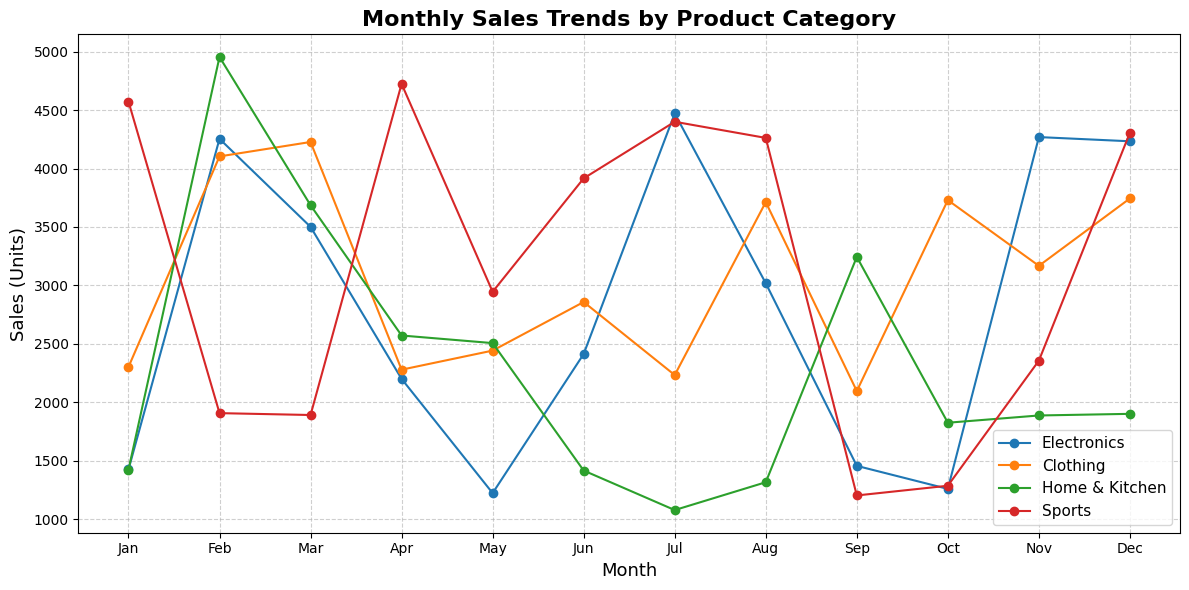

In [ ]:
# Plot 1: Monthly Sales Trends
plt.figure(figsize=(12, 6))

for category in categories:
    plt.plot(months, df[category], marker='o', label=category)

plt.title('Monthly Sales Trends by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Sales (Units)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Step 2: Box Plot for Sales Distribution

A box plot is used to show the distribution of sales values for each category

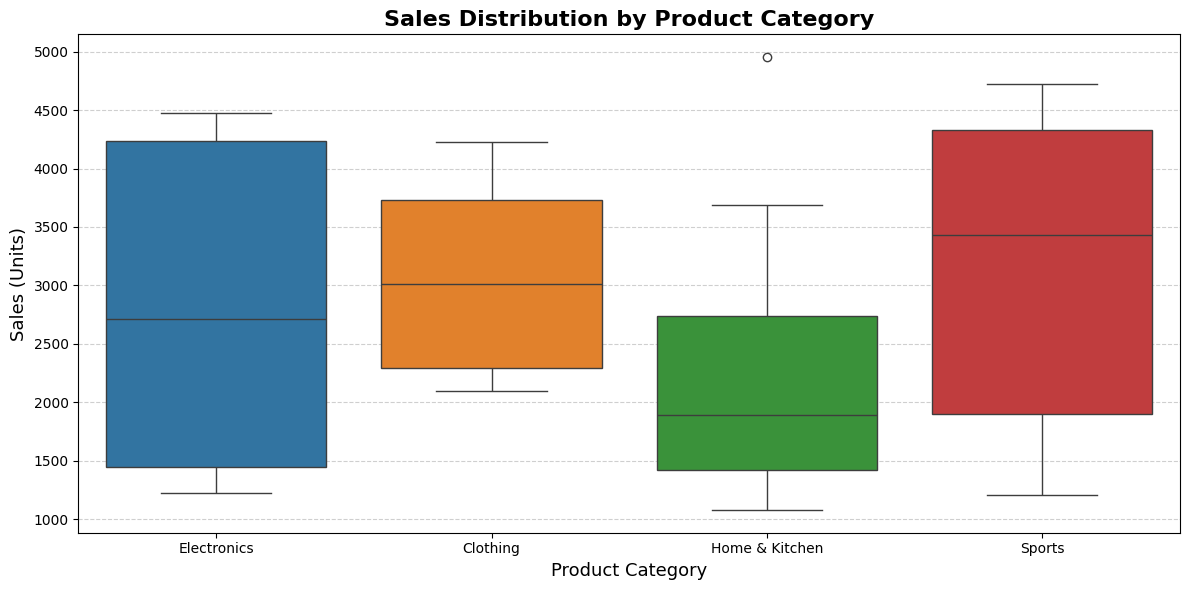

In [ ]:
#Plot 2: Box Plots - Sales Distribution per Category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[categories])
plt.title('Sales Distribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=13)
plt.ylabel('Sales (Units)', fontsize=13)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])

i. Find element-wise absolute value

ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each row.

iii. Mean, Median and Standard Deviation of flattened array, of each column, and
each row.

In [ ]:
array = np.array([[1,-2,3], [-4, 5, -6]])
print("Original Array: ")
print(array)

Original Array: 
[[ 1 -2  3]
 [-4  5 -6]]


In [ ]:
# i. Elementwise Absolute Value
abs_array = np.abs(array)
print("Elementwise Absolute Value: ")
print(abs_array)

Elementwise Absolute Value: 
[[1 2 3]
 [4 5 6]]


In [ ]:
# ii. 25th, 50th, and 75th Percentile
flattened_array = array.flatten()
Percentiles = [25, 50, 75]
print("Percentiles of Flattened Array: ")
print(np.percentile(flattened_array, Percentiles))

print("Percentiles for Each Column: ")
print(np.percentile(array, Percentiles, axis=0))

print("Percentiles for Each Row: ")
print(np.percentile(array, Percentiles, axis=1))


Percentiles of Flattened Array: 
[-3.5 -0.5  2.5]
Percentiles for Each Column: 
[[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]
Percentiles for Each Row: 
[[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]


In [ ]:
# iii. Mean, Median, Standard Deviation
print("Flattened Array: ")
print(f"Mean: {np.mean(flattened_array):.4f}")
print(f"Median: {np.median(flattened_array):.4f}")
print(f"Standard Deviation: {np.std(flattened_array):.4f}")

print("\nEach Column: ")
print(f"Mean: {np.mean(array, axis=0)}")
print(f"Median: {np.median(array, axis=0)}")
print(f"Standard Deviation: {np.std(array, axis=0)}")

print("\nEach Row: ")
print(f"Mean: {np.mean(array, axis=1)}")
print(f"Median: {np.median(array, axis=1)}")
print(f"Standard Deviation: {np.std(array, axis=1)}")


Flattened Array: 
Mean: -0.5000
Median: -0.5000
Standard Deviation: 3.8622

Each Column: 
Mean: [-1.5  1.5 -1.5]
Median: [-1.5  1.5 -1.5]
Standard Deviation: [2.5 3.5 4.5]

Each Row: 
Mean: [ 0.66666667 -1.66666667]
Median: [ 1. -4.]
Standard Deviation: [2.05480467 4.78423336]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).

i. Find floor, ceiling and truncated value, rounded values

In [ ]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Original Array: ")
print(a)

print("\nFloor Values: ")
# Rounds Down to nearest integer
print(np.floor(a))

print("\nCeiling Values: ")
# Rounds Up to nearest integer
print(np.ceil(a))

print("\nTruncated Values: ")
# Removes decimal part
print(np.trunc(a))

print("\nRounded Values: ")
# Rounds to nearest even integer
print(np.round(a))

Original Array: 
[-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]

Floor Values: 
[-2. -2. -1.  0.  1.  1.  3.]

Ceiling Values: 
[-1. -1. -0.  1.  2.  2.  3.]

Truncated Values: 
[-1. -1. -0.  0.  1.  1.  3.]

Rounded Values: 
[-2. -2. -0.  0.  2.  2.  3.]


Q.4 WAP to swap two elements in a list in Python Using a Temporary Variable.

In [ ]:
# Swap elements in a list using a temporary variable
my_list = [10, 20, 30, 40, 50]
print(f"Original List: {my_list}")

# Positions to swap index 1 (value=20) and index 3 (value=40)
i = 1
j = 3

# Save element at index i into a temporary variable
temp = my_list[i]

# Place element at index j into index i
my_list[i] = my_list[j]

# Place the saved temp value into index j
my_list[j] = temp

print(f"List after swapping index {i} and {j}: {my_list}")

Original List: [10, 20, 30, 40, 50]
List after swapping index 1 and 3: [10, 40, 30, 20, 50]


Q.5 Write a Python program to swap two elements in a set by converting it to a list first.

In [ ]:
# Swap elements in a set by converting to a list first

my_set = {10, 20, 30, 40, 50}
print(f"Original Set: {my_set}")

#Convert set to list
temp_list = list(my_set)
print(f"Set converted to List: {temp_list}")

#Swap elements at index 0 and index 2 using temp variable
i = 0
j = 2

temp = temp_list[i]
temp_list[i] = temp_list[j]
temp_list[j] = temp

print(f"List after swapping index {i} and {j}: {temp_list}")

# Converting back to set
my_set = set(temp_list)
print(f"Converted back to Set: {my_set}")

Original Set: {50, 20, 40, 10, 30}
Set converted to List: [50, 20, 40, 10, 30]
List after swapping index 0 and 2: [40, 20, 50, 10, 30]
Converted back to Set: {40, 10, 50, 20, 30}
